In [3]:
from matplotlib.text import TextPath
from matplotlib.path import Path
from matplotlib.transforms import Affine2D
from matplotlib.patches import Circle, PathPatch
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties


In [56]:
text = 'January'
font_size=1
font_prop = FontProperties(family = 'DejaVu Sans')

In [58]:
def curved_text(ax, text, r, angle_offset=0, font_size=1, font_prop=None):
    """ Add a curved text to an axis. r is the radius of curvature at the text center, angle offset the angle of the text center (in RADIANS)"""

    # Create a TextPath object with the text
    text_path = TextPath((0, 0), text, size=font_size, prop=font_prop)
    bb = text_path.get_extents()
    # Center the text path
    text_centered = Affine2D().translate(-0.5 * (bb.x0 + bb.x1), -0.5 * (bb.y0 + bb.y1)).transform_path(text_path)

    # Curve the text vertexes
    verts = text_centered.vertices
    new_verts = np.array([((r+y)*np.sin(x/r + angle_offset), (r+y)*np.cos(x/r + angle_offset)) for (x,y) in verts])
    text_centered.vertices = new_verts

    # Create a PathPatch from the curved text path and add it to the axis
    patch = PathPatch(text_centered, color='black', linewidth=0)
    ax.add_patch(patch)

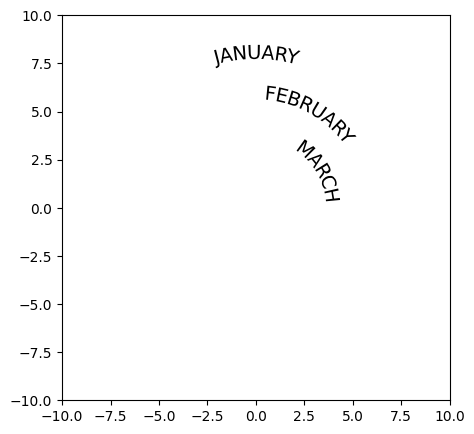

In [60]:
fig, ax = plt.subplots(figsize = (5,5))
ax.set_xlim(-10,10)
ax.set_ylim(-10,10)

angle = 0

for r, t, angle in zip([8,6,4], ['JANUARY', 'FEBRUARY', 'MARCH'], [0, np.pi/6, np.pi/3]):
    curved_text(ax, t, r, font_size=1, angle_offset=angle, font_prop=font_prop)

plt.show()

In [28]:
import numpy as np

array([[-3.09460937e-01,  3.65078125e-02],
       [-2.89742187e-01,  3.65078125e-02],
       [-2.89742187e-01,  6.61718750e-03],
       [-2.18054687e-01,  6.61718750e-03],
       [-2.18054687e-01,  3.65078125e-02],
       [-1.98335937e-01,  3.65078125e-02],
       [-1.98335937e-01, -3.63984375e-02],
       [-2.18054687e-01, -3.63984375e-02],
       [-2.18054687e-01, -1.67968750e-03],
       [-2.89742187e-01, -1.67968750e-03],
       [-2.89742187e-01, -3.63984375e-02],
       [-3.09460937e-01, -3.63984375e-02],
       [-3.09460937e-01,  3.65078125e-02],
       [-3.29085937e-01, -3.63984375e-02],
       [-1.59070312e-01,  3.65078125e-02],
       [-6.68828125e-02,  3.65078125e-02],
       [-6.68828125e-02,  2.81953125e-02],
       [-1.39351562e-01,  2.81953125e-02],
       [-1.39351562e-01,  6.61718750e-03],
       [-6.99140625e-02,  6.61718750e-03],
       [-6.99140625e-02, -1.67968750e-03],
       [-1.39351562e-01, -1.67968750e-03],
       [-1.39351562e-01, -2.81015625e-02],
       [-6.